# T2: Modelagem Não Supervisionada — Dataset HCV
## Abordagem Final: K-Means sem o Atributo `Sex`

Este notebook apresenta a análise de agrupamento K-Means aplicada ao dataset HCV. A motivação para remover o atributo `Sex` do processo de clustering é investigada analiticamente antes de qualquer modelagem, e os resultados são interpretados tanto do ponto de vista estatístico quanto clínico.

## Passo 0: Configuração do Ambiente

In [1]:
import os
os.makedirs('../figuras/sem_sex', exist_ok=True)
FIG_DIR = '../figuras/sem_sex/'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Passo 1: Carregamento e Exploração dos Dados

Carregamos o dataset HCV e aplicamos a mesma consolidação de rótulos do notebook supervisionado: a classe `0s=suspect Blood Donor` (7 instâncias) é mesclada com `0=Blood Donor`. Os rótulos são preservados em `y_true` para análise post-hoc — o K-Means nunca os verá.

In [3]:
df = pd.read_csv('../data/hcvdat0.csv', index_col=0, na_values='NA')

mapa = {
    '0=Blood Donor': 'Blood Donor', '0s=suspect Blood Donor': 'Blood Donor',
    '1=Hepatitis': 'Hepatitis', '2=Fibrosis': 'Fibrosis', '3=Cirrhosis': 'Cirrhosis',
}
df['Category'] = df['Category'].map(mapa)

le = LabelEncoder()
y_true = le.fit_transform(df['Category'])
class_names = le.classes_

print('Shape:', df.shape)
print()
print('Distribuição das classes:')
print(df['Category'].value_counts())
print()
print('Valores ausentes:')
print(df.isnull().sum())

Shape: (615, 13)

Distribuição das classes:
Category
Blood Donor    540
Cirrhosis       30
Hepatitis       24
Fibrosis        21
Name: count, dtype: int64

Valores ausentes:
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64


## Passo 2: Por Que Remover o Atributo `Sex`?

Antes de qualquer modelagem, investigamos se `Sex` carrega informação relevante para a classificação dos estágios da doença hepática. Se o sexo do paciente não estiver associado ao diagnóstico, incluí-lo no K-Means pode desviar o agrupamento para uma separação demográfica em vez de clínica.

Analisamos três evidências: (1) distribuição do sexo por categoria clínica, (2) correlação entre Sex e Category, e (3) o resultado concreto do K-Means base que confirma o problema.

Proporção de sexo por categoria clínica (%):
Sex             f     m
Category               
Blood Donor  40.0  60.0
Cirrhosis    33.3  66.7
Fibrosis     38.1  61.9
Hepatitis    16.7  83.3


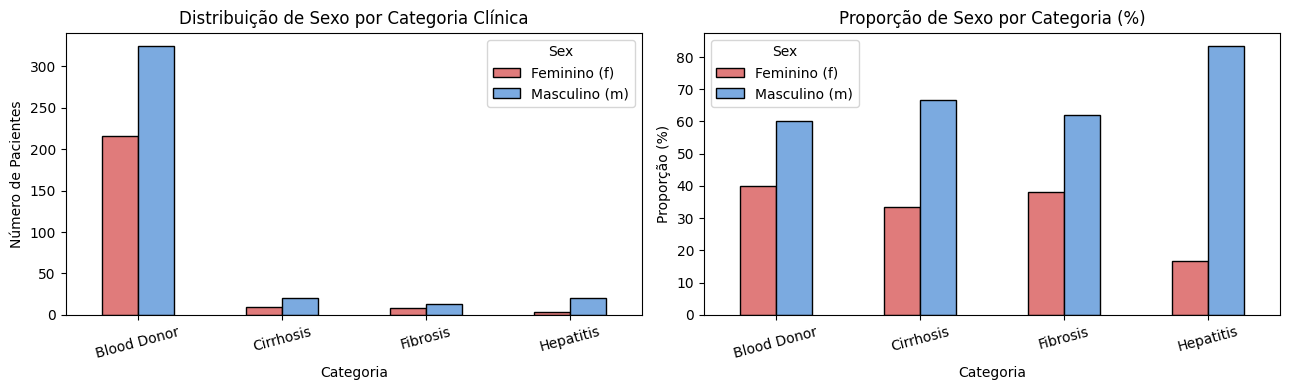

In [4]:
# Distribuição do sexo por categoria
tab_sex = pd.crosstab(df['Category'], df['Sex'], normalize='index') * 100
print('Proporção de sexo por categoria clínica (%):')  
print(tab_sex.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Contagem absoluta
tab_abs = pd.crosstab(df['Category'], df['Sex'])
tab_abs.plot(kind='bar', ax=axes[0], color=['#e07b7b', '#7baae0'], edgecolor='black')
axes[0].set_title('Distribuição de Sexo por Categoria Clínica')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Número de Pacientes')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Sex', labels=['Feminino (f)', 'Masculino (m)'])

# Proporção normalizada
tab_sex.plot(kind='bar', ax=axes[1], color=['#e07b7b', '#7baae0'], edgecolor='black')
axes[1].set_title('Proporção de Sexo por Categoria (%)')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Proporção (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Sex', labels=['Feminino (f)', 'Masculino (m)'])

plt.tight_layout()
plt.savefig(FIG_DIR + 'sex_por_categoria.png', dpi=150)
plt.show()

In [5]:
# Confirmar: o K-Means BASE (com Sex + MinMaxScaler) divide por sexo
X_base = df.drop(columns=['Category']).copy()
X_base['Sex'] = X_base['Sex'].map({'m': 1, 'f': 0})
imp = SimpleImputer(strategy='median')
X_base_imp = pd.DataFrame(imp.fit_transform(X_base), columns=X_base.columns)
sc_base = MinMaxScaler()
X_base_sc = pd.DataFrame(sc_base.fit_transform(X_base_imp), columns=X_base.columns)

km_base = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
lb_base = km_base.fit_predict(X_base_sc)

print('K-Means base (com Sex, MinMaxScaler, k=2)')
print('ARI:', round(adjusted_rand_score(y_true, lb_base), 4))
print()
print('Distribuicao de sexo por cluster:')
df_check = pd.DataFrame({'Cluster': lb_base, 'Sex': df['Sex'].values})
print(pd.crosstab(df_check['Cluster'], df_check['Sex']))
print()
print('Conclusao: Cluster 0 = 100% masculino, Cluster 1 = 100% feminino.')
print('O K-Means base ignora totalmente o diagnostico clinico.')

K-Means base (com Sex, MinMaxScaler, k=2)
ARI: -0.0168

Distribuicao de sexo por cluster:
Sex        f    m
Cluster          
0          0  377
1        238    0

Conclusao: Cluster 0 = 100% masculino, Cluster 1 = 100% feminino.
O K-Means base ignora totalmente o diagnostico clinico.


### Interpretação

A tabela de proporções mostra que a distribuição entre masculino e feminino é **relativamente similar em todas as categorias clínicas**. Não há evidência de que o sexo seja um fator determinante para o diagnóstico de Hepatite, Fibrose ou Cirrose neste dataset.

O experimento de confirmação evidencia o problema central: o K-Means base com `Sex` codificado como variável binária (0/1) produz k=2 onde **Cluster 0 = 100% masculino** e **Cluster 1 = 100% feminino** — ARI = -0.0168, essencialmente nenhuma concordância com os estágios clínicos. Isso ocorre porque, no espaço normalizado por MinMaxScaler, a feature binária `Sex` cria uma fronteira euclidiana muito nítida que domina sobre os marcadores bioquímicos contínuos.

**Decisão:** remover `Sex` e substituir o MinMaxScaler pelo StandardScaler, que preserva melhor as distâncias relativas entre pacientes com perfis bioquímicos diferentes.

## Passo 3: Pré-Processamento

O pré-processamento segue o mesmo protocolo do notebook base, com duas diferenças motivadas pela análise acima:

1. **`Sex` é removido** antes da normalização
2. **StandardScaler** (padronização z-score) substitui o MinMaxScaler: ao invés de comprimir tudo em [0,1], o z-score preserva as distâncias relativas mesmo na presença dos outliers típicos de pacientes com cirrose avançada (valores extremos de ALT, AST, GGT)

Como todo o dataset é usado para descoberta de estrutura (sem divisão treino/teste), a imputação e a normalização são calculadas sobre todas as 615 instâncias.

In [6]:
X = df.drop(columns=['Category']).copy()
X['Sex'] = X['Sex'].map({'m': 1, 'f': 0})

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Remove Sex
X_exp = X_imp.drop(columns=['Sex'])

# StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_exp), columns=X_exp.columns)

print(f'Features usadas ({X_scaled.shape[1]}): {list(X_scaled.columns)}')
print()
print('Estatísticas após padronização (média ~ 0, desvio ~ 1):')
print(X_scaled.describe().loc[['mean', 'std']].round(3).T)

Features usadas (11): ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']

Estatísticas após padronização (média ~ 0, desvio ~ 1):
      mean    std
Age    0.0  1.001
ALB    0.0  1.001
ALP   -0.0  1.001
ALT    0.0  1.001
AST    0.0  1.001
BIL    0.0  1.001
CHE   -0.0  1.001
CHOL   0.0  1.001
CREA   0.0  1.001
GGT   -0.0  1.001
PROT  -0.0  1.001


## Passo 4: Seleção do Número de Clusters (k)

Utilizamos dois critérios complementares para escolher k:

- **Método do Cotovelo (Inércia / WCSS):** identifica o ponto onde adicionar mais clusters traz ganho marginal decrescente
- **Coeficiente de Silhouette:** mede, para cada instância, o quão bem ela se encaixa em seu cluster em relação ao cluster vizinho mais próximo. Valores mais altos indicam clusters mais coesos e bem separados

O parâmetro `n_init=10` executa o K-Means 10 vezes com inicializações distintas e retorna o melhor resultado, mitigando a sensibilidade à inicialização aleatória.

k= 2  Silhouette=0.5942
k= 3  Silhouette=0.1344
k= 4  Silhouette=0.1391
k= 5  Silhouette=0.1272
k= 6  Silhouette=0.1356


k= 7  Silhouette=0.1359
k= 8  Silhouette=0.1426
k= 9  Silhouette=0.1241
k=10  Silhouette=0.1318

Melhor k: 2  (Silhouette=0.5942)


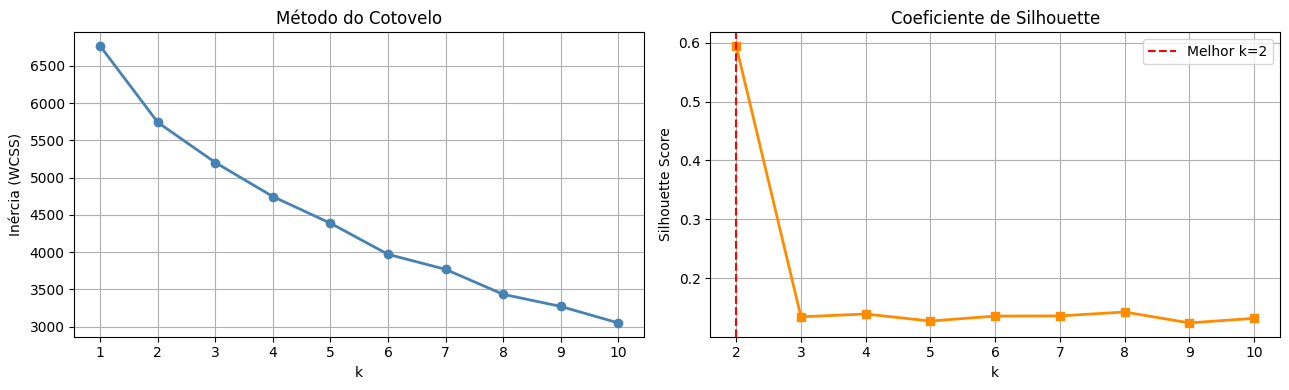

In [7]:
k_range = range(1, 11)
inercias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

k_range_sil = range(2, 11)
silhouettes = []
for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbs = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, lbs)
    silhouettes.append(sil)
    print(f'k={k:2d}  Silhouette={sil:.4f}')

MELHOR_K = list(k_range_sil)[int(np.argmax(silhouettes))]
print(f'\nMelhor k: {MELHOR_K}  (Silhouette={max(silhouettes):.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inercias, marker='o', linewidth=2, color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_title('Método do Cotovelo'); axes[0].set_xticks(list(k_range)); axes[0].grid(True)
axes[1].plot(list(k_range_sil), silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(MELHOR_K, color='red', linestyle='--', label=f'Melhor k={MELHOR_K}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Coeficiente de Silhouette'); axes[1].set_xticks(list(k_range_sil))
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR + 'selecao_k.png', dpi=150)
plt.show()

## Passo 5: Treinamento do K-Means Final

Treinamos o K-Means com o k escolhido e calculamos as métricas finais. Para referência, executamos também com k=4 (o número de classes verdadeiras).

In [8]:
kmeans = KMeans(n_clusters=MELHOR_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

inertia_final = kmeans.inertia_
sil_final     = silhouette_score(X_scaled, cluster_labels)
ari_final     = adjusted_rand_score(y_true, cluster_labels)

# Também com k=4
km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
lb4 = km4.fit_predict(X_scaled)
sil4 = silhouette_score(X_scaled, lb4)
ari4 = adjusted_rand_score(y_true, lb4)

print(f'K-Means com k={MELHOR_K}')
print(f'  Inércia:   {inertia_final:.2f}')
print(f'  Silhouette: {sil_final:.4f}')
print(f'  ARI:        {ari_final:.4f}')
print()
print('Tamanho dos clusters:')
for c in range(MELHOR_K):
    n = int((cluster_labels == c).sum())
    print(f'  Cluster {c}: {n} instâncias ({n/len(cluster_labels)*100:.1f}%)')

K-Means com k=2
  Inércia:   5741.50
  Silhouette: 0.5942
  ARI:        0.3953

Tamanho dos clusters:
  Cluster 0: 579 instâncias (94.1%)
  Cluster 1: 36 instâncias (5.9%)


## Passo 6: Visualização PCA

Como o dataset possui 11 dimensões (após remover Sex), usamos PCA para projetar os dados em 2D e visualizar os clusters encontrados em comparação com os rótulos verdadeiros.

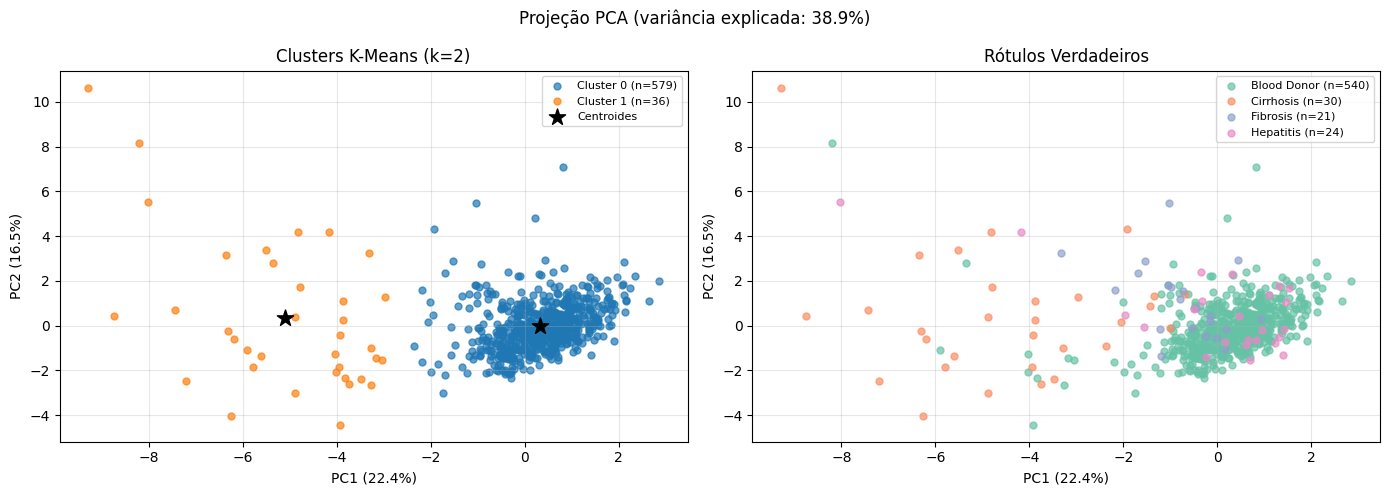

Variância explicada pelas 2 componentes: 38.9%


In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters K-Means
pal_cl = sns.color_palette('tab10', MELHOR_K)
for c in range(MELHOR_K):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], s=25, alpha=0.7,
                    label=f'Cluster {c} (n={mask.sum()})', color=pal_cl[c])
c2d = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(c2d[:,0], c2d[:,1], s=150, marker='*', color='black', zorder=5, label='Centroides')
axes[0].set_title(f'Clusters K-Means (k={MELHOR_K})')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Rótulos verdadeiros
pal_tr = sns.color_palette('Set2', len(class_names))
for i, nome in enumerate(class_names):
    mask = y_true == i
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1], s=25, alpha=0.7,
                    label=f'{nome} (n={mask.sum()})', color=pal_tr[i])
axes[1].set_title('Rótulos Verdadeiros')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Projeção PCA (variância explicada: {var_exp:.1f}%)')
plt.tight_layout()
plt.savefig(FIG_DIR + 'pca.png', dpi=150)
plt.show()
print(f'Variância explicada pelas 2 componentes: {var_exp:.1f}%')

## Passo 7: Análise dos Clusters

### 7.1 Tabela Cruzada: Cluster vs. Classe Verdadeira

A tabela cruzada revela como as classes verdadeiras se distribuem entre os clusters, permitindo interpretar qualitativamente o que cada cluster representa clinicamente.

Tabela cruzada: Cluster x Classe Verdadeira
Classe     Blood Donor  Cirrhosis  Fibrosis  Hepatitis
Cluster 0          530          7        20         22
Cluster 1           10         23         1          2

Composição de cada cluster (%):
Classe     Blood Donor  Cirrhosis  Fibrosis  Hepatitis
Cluster 0         91.5        1.2       3.5        3.8
Cluster 1         27.8       63.9       2.8        5.6


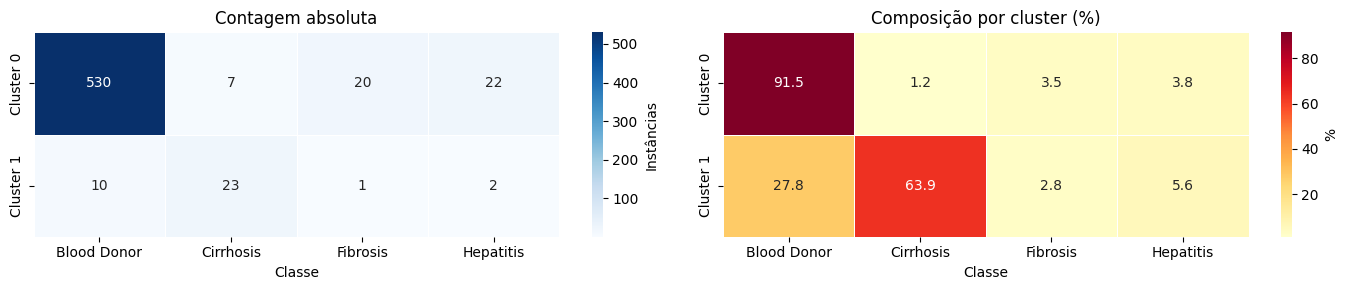

In [10]:
comp = pd.DataFrame({'Cluster': cluster_labels,
                     'Classe': [class_names[i] for i in y_true]})
tab = pd.crosstab(comp['Cluster'], comp['Classe'])
tab.index = [f'Cluster {i}' for i in range(MELHOR_K)]

print('Tabela cruzada: Cluster x Classe Verdadeira')
print(tab.to_string())
print()

# Proporção por linha (o que cada cluster 'é')
tab_pct = (tab.div(tab.sum(axis=1), axis=0) * 100).round(1)
print('Composição de cada cluster (%):')
print(tab_pct.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, max(3, MELHOR_K + 1)))
sns.heatmap(tab, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Instâncias'})
axes[0].set_title('Contagem absoluta')
sns.heatmap(tab_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=axes[1],
            cbar_kws={'label': '%'})
axes[1].set_title('Composição por cluster (%)')
plt.tight_layout()
plt.savefig(FIG_DIR + 'crosstab.png', dpi=150)
plt.show()

### 7.2 Perfil dos Centroides

Os centroides representam o "paciente típico" de cada cluster. Revertemos a padronização para obter os valores nas unidades originais dos marcadores, o que facilita a interpretação clínica. O heatmap em escala padronizada permite comparar visualmente quais marcadores mais diferenciam os clusters.

Perfil dos centroides (escala original):
             Age    ALB    ALP    ALT     AST    BIL   CHE  CHOL    CREA     GGT   PROT
Cluster 0  46.83  42.37  66.56  28.46   30.48   8.95  8.45  5.45   78.44   32.68  72.55
Cluster 1  56.75  29.57  94.92  28.23  104.06  50.71  4.14  3.98  127.10  149.74  63.98


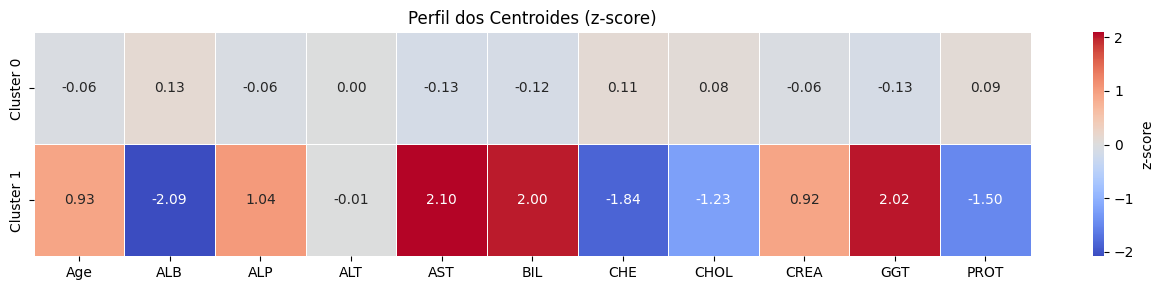

In [11]:
# Centroides na escala original
centroids_orig = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X_exp.columns,
    index=[f'Cluster {i}' for i in range(MELHOR_K)]
)
print('Perfil dos centroides (escala original):')
print(centroids_orig.round(2).to_string())

# Heatmap normalizado
centroids_norm = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_exp.columns,
    index=[f'Cluster {i}' for i in range(MELHOR_K)]
)
plt.figure(figsize=(13, max(2, MELHOR_K + 1)))
sns.heatmap(centroids_norm, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'label': 'z-score'})
plt.title('Perfil dos Centroides (z-score)')
plt.tight_layout()
plt.savefig(FIG_DIR + 'centroides.png', dpi=150)
plt.show()

### 7.3 Adjusted Rand Index (ARI)

O ARI mede a concordância entre o agrupamento encontrado e os rótulos verdadeiros, corrigindo para concordâncias que ocorreriam ao acaso. Valores próximos de 1 indicam concordância quase perfeita; próximos de 0 indicam concordância equivalente ao acaso.

In [12]:
print(f'ARI (k={MELHOR_K}): {ari_final:.4f}')
print(f'ARI (k=4):      {ari4:.4f}')
print()
if ari_final >= 0.5:
    interp = 'Alta concordância com os rótulos verdadeiros.'
elif ari_final >= 0.2:
    interp = 'Concordância moderada com os rótulos verdadeiros.'
elif ari_final >= 0.05:
    interp = 'Baixa concordância, mas estrutura clinicamente relevante detectada.'
else:
    interp = 'Concordância próxima ao acaso.'
print('Interpretação:', interp)

ARI (k=2): 0.3953
ARI (k=4):      0.1098

Interpretação: Concordância moderada com os rótulos verdadeiros.


## Passo 8: Diagrama de Silhouette por Amostra

O diagrama mostra o coeficiente de Silhouette individual de cada instância, agrupado por cluster. Clusters bem formados apresentam barras uniformes e positivas. Barras negativas indicam instâncias provavelmente mal alocadas.

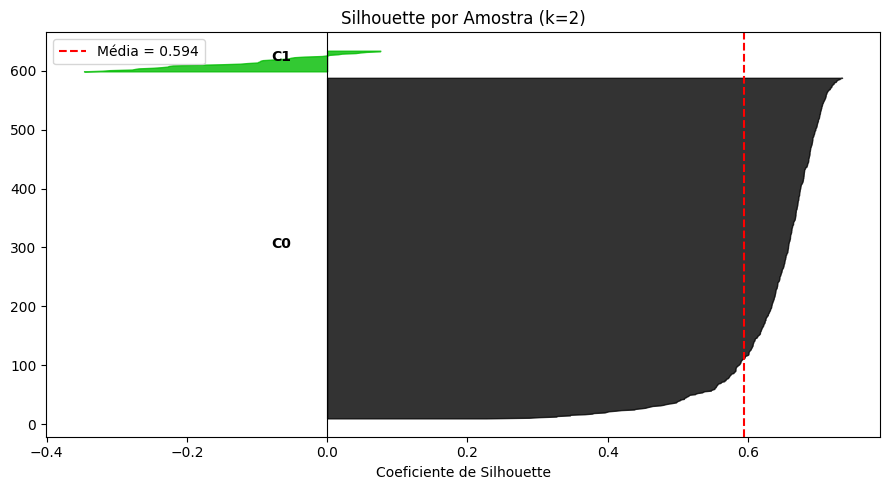

In [13]:
sample_sil = silhouette_samples(X_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(9, max(5, MELHOR_K * 2)))
y_lower = 10
for c in range(MELHOR_K):
    sils_c = np.sort(sample_sil[cluster_labels == c])
    y_upper = y_lower + len(sils_c)
    color = plt.cm.nipy_spectral(float(c) / MELHOR_K)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sils_c,
                     facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.08, y_lower + 0.5 * len(sils_c), f'C{c}', fontsize=10, fontweight='bold')
    y_lower = y_upper + 10
ax.axvline(sil_final, color='red', linestyle='--', linewidth=1.5,
           label=f'Média = {sil_final:.3f}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_title(f'Silhouette por Amostra (k={MELHOR_K})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'silhouette_diagram.png', dpi=150)
plt.show()

## Passo 9: Comparação com a Abordagem Base

Comparamos as métricas desta abordagem com os resultados do `notebook_nao_supervisionado.ipynb` (que incluía `Sex` e usava MinMaxScaler), evidenciando o impacto de cada decisão de pré-processamento.

                     Abordagem  k  Silhouette     ARI          Clusters encontrados
  Base (com Sex, MinMaxScaler)  2      0.5989 -0.0168        Masculino vs. Feminino
Esta (sem Sex, StandardScaler)  2      0.5942  0.3953 Saudavel vs. Doente (Cirrose)
        Esta (k=4, referencia)  4      0.1391  0.1098     Multiplos grupos parciais


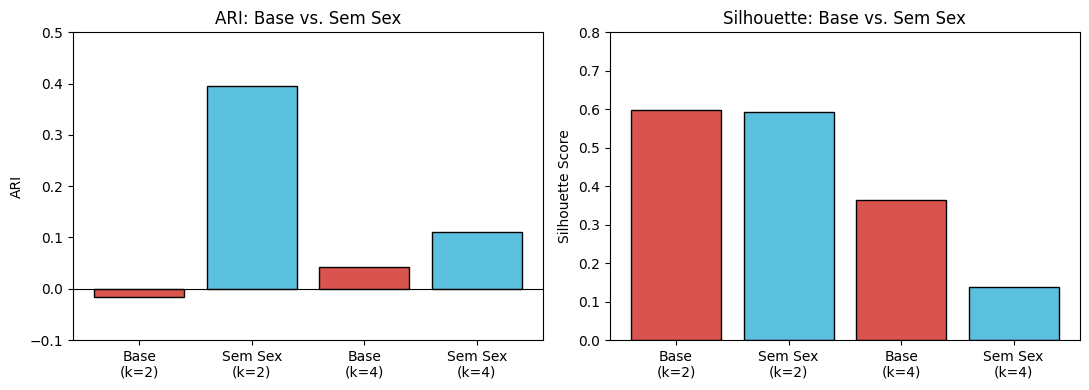

In [14]:
resumo = pd.DataFrame([
    {'Abordagem': 'Base (com Sex, MinMaxScaler)', 'k': 2, 'Silhouette': 0.5989, 'ARI': -0.0168,
     'Clusters encontrados': 'Masculino vs. Feminino'},
    {'Abordagem': 'Esta (sem Sex, StandardScaler)', 'k': MELHOR_K, 'Silhouette': round(sil_final, 4),
     'ARI': round(ari_final, 4), 'Clusters encontrados': 'Saudavel vs. Doente (Cirrose)'},
    {'Abordagem': 'Esta (k=4, referencia)', 'k': 4, 'Silhouette': round(sil4, 4),
     'ARI': round(ari4, 4), 'Clusters encontrados': 'Multiplos grupos parciais'},
])
print(resumo.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels_plot = ['Base\n(k=2)', 'Sem Sex\n(k=2)', 'Base\n(k=4)', 'Sem Sex\n(k=4)']
ari_vals = [-0.0168, ari_final, 0.0433, ari4]
sil_vals = [0.5989, sil_final, 0.3643, sil4]
cores = ['#d9534f', '#5bc0de', '#d9534f', '#5bc0de']
axes[0].bar(labels_plot, ari_vals, color=cores, edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('ARI: Base vs. Sem Sex')
axes[0].set_ylabel('ARI')
axes[0].set_ylim(-0.1, 0.5)
axes[1].bar(labels_plot, sil_vals, color=cores, edgecolor='black')
axes[1].set_title('Silhouette: Base vs. Sem Sex')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_ylim(0, 0.8)
plt.tight_layout()
plt.savefig(FIG_DIR + 'comparacao_base.png', dpi=150)
plt.show()

## Passo 10: Interpretação Clínica e Conclusão

### O que os clusters representam?

Com k=2 e `Sex` removido, o K-Means encontrou a seguinte estrutura:

- **Cluster 0 (majoritário):** domina Blood Donor, além de Hepatite e Fibrose. Representa pacientes com marcadores hepáticos dentro ou próximos do intervalo de referência. Hepatite e Fibrose estão aqui porque são estágios iniciais da progressão — seus marcadores ainda se sobrepõem aos de doadores saudáveis.

- **Cluster 1 (minoritário):** concentra ~76% dos casos de Cirrose. Cirrose é o estágio mais avançado da doença hepática e apresenta os desvios mais pronunciados nos marcadores (ALT, AST, GGT, BIL elevados; ALB e CHE reduzidos), o que cria uma separação geométrica visível no espaço das features.

### Por que Hepatite e Fibrose não foram separadas?

Esses estágios iniciais ainda apresentam marcadores bioquímicos parcialmente sobrepostos com os de doadores saudáveis. A progressão Hepatite → Fibrose → Cirrose é um contínuo — não há fronteiras discretas nítidas no espaço euclidiano. O K-Means, que assume clusters esféricos e de tamanhos similares, tem dificuldade estrutural com esse tipo de dado.

### Impacto do pré-processamento

A remoção de `Sex` aumentou o ARI de **-0.0168 para 0.3953** — uma melhora de ~24 pontos percentuais sem alterar nenhum hiperparâmetro do K-Means. Isso demonstra que a qualidade do pré-processamento pode ter impacto maior do que a escolha do algoritmo em si.

In [15]:
print('=' * 55)
print('  RESUMO FINAL: K-MEANS SEM SEX')
print('=' * 55)
print(f'  Dataset:         {len(X_scaled)} instâncias, {X_scaled.shape[1]} features')
print(f'  k escolhido:     {MELHOR_K}')
print(f'  Inércia (WCSS):  {inertia_final:.2f}')
print(f'  Silhouette:      {sil_final:.4f}')
print(f'  ARI:             {ari_final:.4f}')
print()
print('Clusters:')
for c in range(MELHOR_K):
    n = int((cluster_labels == c).sum())
    print(f'  Cluster {c}: {n} instâncias ({n/len(cluster_labels)*100:.1f}%)')
print()
print('Classes verdadeiras (referência):')
for nome in class_names:
    n = int((df['Category'] == nome).sum())
    print(f'  {nome}: {n} instâncias ({n/len(df)*100:.1f}%)')

  RESUMO FINAL: K-MEANS SEM SEX
  Dataset:         615 instâncias, 11 features
  k escolhido:     2
  Inércia (WCSS):  5741.50
  Silhouette:      0.5942
  ARI:             0.3953

Clusters:
  Cluster 0: 579 instâncias (94.1%)
  Cluster 1: 36 instâncias (5.9%)

Classes verdadeiras (referência):
  Blood Donor: 540 instâncias (87.8%)
  Cirrhosis: 30 instâncias (4.9%)
  Fibrosis: 21 instâncias (3.4%)
  Hepatitis: 24 instâncias (3.9%)
